In [1]:
import warnings
warnings.filterwarnings("ignore")

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

conn = psycopg2.connect(
    host="127.0.0.1", port=5455, dbname="postgres",
    user="postgres", password="postgres"
)
print("Connected ✓")

Connected ✓


In [2]:
cur = conn.cursor()
cur.execute("""
    SELECT
        f.team_name,
        f.season,
        f.conference,
        f.avg_points_scored,
        f.avg_points_allowed,
        f.avg_point_diff,
        f.off_epa_per_play,
        f.def_epa_per_play,
        f.wins,
        f.losses,
        f.games_played
    FROM int.int_team_season_features f
    WHERE f.games_played > 0
    ORDER BY f.season, f.team_name
""")

rows = cur.fetchall()
cols = [d[0] for d in cur.description]
df = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "avg_points_scored", "avg_points_allowed", "avg_point_diff",
    "off_epa_per_play", "def_epa_per_play",
    "wins", "losses", "games_played",
]
df[numeric_cols] = df[numeric_cols].astype(float)

print(f"Rows: {len(df):,}   Teams: {df['team_name'].nunique()}   Seasons: {sorted(df['season'].unique())}")
print(f"Conferences: {sorted(df['conference'].unique())}")
print(df.dtypes)

Rows: 534   Teams: 136   Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Conferences: ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'FBS Independents', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']
team_name              object
season                  int64
conference             object
avg_points_scored     float64
avg_points_allowed    float64
avg_point_diff        float64
off_epa_per_play      float64
def_epa_per_play      float64
wins                  float64
losses                float64
games_played          float64
dtype: object


In [3]:
P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

df["tier"] = df.apply(assign_tier, axis=1)

print(df["tier"].value_counts())
print(f"\nNull check:\n{df.isnull().sum()}")

tier
G5    288
P4    246
Name: count, dtype: int64

Null check:
team_name             0
season                0
conference            0
avg_points_scored     0
avg_points_allowed    0
avg_point_diff        0
off_epa_per_play      0
def_epa_per_play      0
wins                  0
losses                0
games_played          0
tier                  0
dtype: int64


In [4]:
def compute_icc(data, col, group_col="conference"):
    sub     = data.dropna(subset=[col])
    grand   = sub[col].mean()
    g_stats = sub.groupby(group_col)[col].agg(n="count", mean="mean").reset_index()
    ss_b    = np.sum(g_stats["n"] * (g_stats["mean"] - grand) ** 2)
    ss_t    = np.sum((sub[col] - grand) ** 2)
    return ss_b / ss_t

In [5]:
# Grand mean of avg_points_scored across all team-seasons
grand_mean = df["avg_points_scored"].mean()
grand_n    = len(df)

# Between-conference variance:
# For each conference, compute its mean. SS_between = sum over conferences of
# n_conf * (conf_mean - grand_mean)^2
conf_stats = (
    df.groupby("conference")["avg_points_scored"]
    .agg(n="count", mean="mean")
    .reset_index()
)
ss_between = np.sum(conf_stats["n"] * (conf_stats["mean"] - grand_mean) ** 2)

# Within-conference variance:
# For each team-season, (score - conf_mean)^2
df["conf_mean_scored"] = df.groupby("conference")["avg_points_scored"].transform("mean")
ss_within = np.sum((df["avg_points_scored"] - df["conf_mean_scored"]) ** 2)

ss_total  = np.sum((df["avg_points_scored"] - grand_mean) ** 2)

pct_between = ss_between / ss_total * 100
pct_within  = ss_within  / ss_total * 100

print("=" * 60)
print("Q1 — Variance decomposition: avg_points_scored")
print("=" * 60)
print(f"  SS total    : {ss_total:,.1f}")
print(f"  SS between  : {ss_between:,.1f}  ({pct_between:.1f}%)")
print(f"  SS within   : {ss_within:,.1f}  ({pct_within:.1f}%)")
print()

# Repeat for avg_point_diff — more directly

Q1 — Variance decomposition: avg_points_scored
  SS total    : 23,830.7
  SS between  : 2,219.6  (9.3%)
  SS within   : 21,611.1  (90.7%)



In [6]:
conf_within = (
    df.groupby("conference")["avg_points_scored"]
    .agg(n="count", mean="mean", std="std", var="var")
    .reset_index()
    .sort_values("var", ascending=False)
)
conf_within["cv"] = conf_within["std"] / conf_within["mean"]

print("=" * 70)
print("Q2 — Within-conference variance (avg_points_scored)")
print("=" * 70)
print(f"{'conference':<25} {'n':>4} {'mean':>7} {'std':>7} {'var':>8} {'cv':>6}")
print("-" * 70)
for _, row in conf_within.iterrows():
    print(f"{row['conference']:<25} {row['n']:>4.0f} {row['mean']:>7.2f} "
          f"{row['std']:>7.2f} {row['var']:>8.2f} {row['cv']:>6.3f}")

# Flag conferences where within-variance is more than 2 SD above mean within-variance
mean_var = conf_within["var"].mean()
std_var  = conf_within["var"].std()
flagged  = conf_within[conf_within["var"] > mean_var + 2 * std_var]
print(f"\nFlagged (var > mean+2SD = {mean_var + 2*std_var:.1f}):")
if len(flagged):
    print(flagged[["conference", "var"]].to_string(index=False))
else:
    print("  None — within-variance is relatively uniform across conferences")

Q2 — Within-conference variance (avg_points_scored)
conference                   n    mean     std      var     cv
----------------------------------------------------------------------
FBS Independents            16   28.30    8.49    72.05  0.300
Pac-12                      28   30.41    8.36    69.95  0.275
Big Ten                     64   26.60    7.49    56.06  0.282
American Athletic           53   29.27    6.88    47.34  0.235
Mountain West               48   25.77    6.25    39.12  0.243
ACC                         62   28.46    6.21    38.60  0.218
Big 12                      56   29.90    6.17    38.11  0.206
SEC                         60   30.68    6.09    37.08  0.198
Conference USA              42   26.41    5.70    32.47  0.216
Sun Belt                    56   27.87    5.51    30.35  0.198
Mid-American                49   23.83    4.94    24.37  0.207

Flagged (var > mean+2SD = 75.5):
  None — within-variance is relatively uniform across conferences


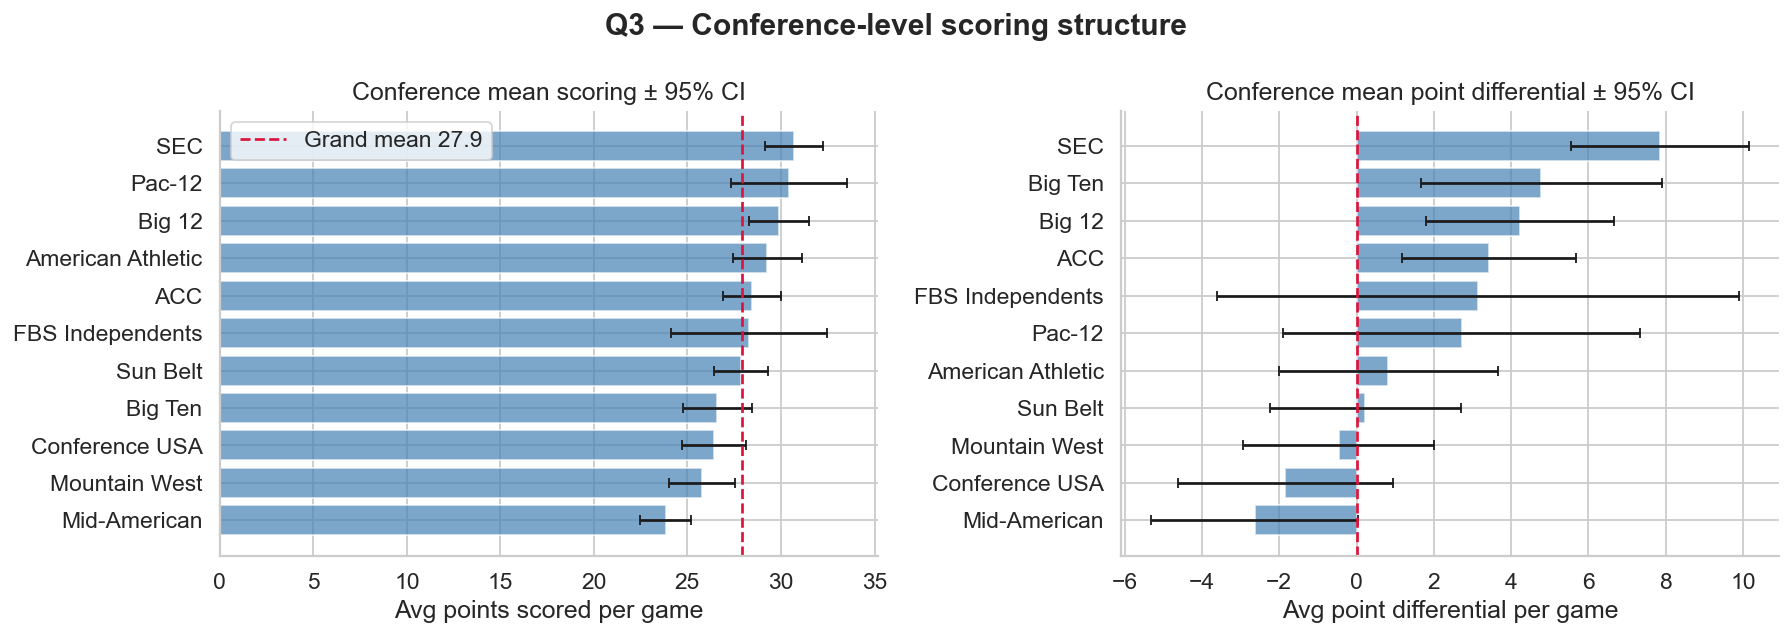


Conference mean point differential (sorted):
       conference      mean
              SEC  7.853333
          Big Ten  4.779375
           Big 12  4.235893
              ACC  3.426452
 FBS Independents  3.151250
           Pac-12  2.718929
American Athletic  0.822830
         Sun Belt  0.220357
    Mountain West -0.458750
   Conference USA -1.847619
     Mid-American -2.634490


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: conference mean avg_points_scored with error bars
conf_plot = (
    df.groupby("conference")["avg_points_scored"]
    .agg(mean="mean", sem=stats.sem)
    .reset_index()
    .sort_values("mean", ascending=True)
)
axes[0].barh(conf_plot["conference"], conf_plot["mean"],
             xerr=conf_plot["sem"] * 1.96,
             color="steelblue", alpha=0.7, capsize=3)
axes[0].axvline(grand_mean, color="crimson", lw=1.5, linestyle="--", label=f"Grand mean {grand_mean:.1f}")
axes[0].set_xlabel("Avg points scored per game")
axes[0].set_title("Conference mean scoring ± 95% CI")
axes[0].legend()

# Right: conference mean avg_point_diff
conf_diff_plot = (
    df.groupby("conference")["avg_point_diff"]
    .agg(mean="mean", sem=stats.sem)
    .reset_index()
    .sort_values("mean", ascending=True)
)
axes[1].barh(conf_diff_plot["conference"], conf_diff_plot["mean"],
             xerr=conf_diff_plot["sem"] * 1.96,
             color="steelblue", alpha=0.7, capsize=3)
axes[1].axvline(0, color="crimson", lw=1.5, linestyle="--")
axes[1].set_xlabel("Avg point differential per game")
axes[1].set_title("Conference mean point differential ± 95% CI")

plt.suptitle("Q3 — Conference-level scoring structure", fontweight="bold")
plt.tight_layout()
plt.show()

# Print conference means sorted high to low for point differential
print("\nConference mean point differential (sorted):")
print(conf_diff_plot.sort_values("mean", ascending=False)[
    ["conference", "mean"]
].to_string(index=False))

In [8]:
# A conference dominates pooling if its mean is more than 1.5 SD from grand mean
grand_mean_diff = df["avg_point_diff"].mean()
grand_std_diff  = df["avg_point_diff"].std()

conf_means_diff = df.groupby("conference")["avg_point_diff"].mean()

print("=" * 65)
print("Q3 — Conference outlier check (avg_point_diff)")
print("=" * 65)
print(f"Grand mean: {grand_mean_diff:.3f}   Grand SD: {grand_std_diff:.3f}")
print(f"Outlier threshold: ±{1.5 * grand_std_diff:.3f} from grand mean")
print()

for conf, mean in conf_means_diff.sort_values(ascending=False).items():
    z = (mean - grand_mean_diff) / grand_std_diff
    flag = "⚠ OUTLIER" if abs(z) > 1.5 else ""
    print(f"  {conf:<25}  mean={mean:+.3f}  z={z:+.2f}  {flag}")

Q3 — Conference outlier check (avg_point_diff)
Grand mean: 2.211   Grand SD: 10.541
Outlier threshold: ±15.812 from grand mean

  SEC                        mean=+7.853  z=+0.54  
  Big Ten                    mean=+4.779  z=+0.24  
  Big 12                     mean=+4.236  z=+0.19  
  ACC                        mean=+3.426  z=+0.12  
  FBS Independents           mean=+3.151  z=+0.09  
  Pac-12                     mean=+2.719  z=+0.05  
  American Athletic          mean=+0.823  z=-0.13  
  Sun Belt                   mean=+0.220  z=-0.19  
  Mountain West              mean=-0.459  z=-0.25  
  Conference USA             mean=-1.848  z=-0.38  
  Mid-American               mean=-2.634  z=-0.46  


In [9]:
icc_scored  = compute_icc(df, "avg_points_scored")
icc_diff    = compute_icc(df, "avg_point_diff")
icc_off_epa = compute_icc(df, "off_epa_per_play")
icc_def_epa = compute_icc(df, "def_epa_per_play")

print("=" * 60)
print("Q4 — ICC: how much variance sits at conference level")
print("=" * 60)
print(f"  avg_points_scored  ICC = {icc_scored:.4f}  ({icc_scored*100:.1f}%)")
print(f"  avg_point_diff     ICC = {icc_diff:.4f}  ({icc_diff*100:.1f}%)")
print(f"  off_epa_per_play   ICC = {icc_off_epa:.4f}  ({icc_off_epa*100:.1f}%)")
print(f"  def_epa_per_play   ICC = {icc_def_epa:.4f}  ({icc_def_epa*100:.1f}%)")
print()
print("Interpretation:")
print("  ICC < 0.05 : conference grouping adds little — flat model adequate")
print("  ICC 0.05–0.15 : modest conference structure — pooling helpful")
print("  ICC > 0.15 : strong conference structure — pooling clearly justified")

Q4 — ICC: how much variance sits at conference level
  avg_points_scored  ICC = 0.0931  (9.3%)
  avg_point_diff     ICC = 0.0875  (8.8%)
  off_epa_per_play   ICC = 0.0939  (9.4%)
  def_epa_per_play   ICC = 0.0701  (7.0%)

Interpretation:
  ICC < 0.05 : conference grouping adds little — flat model adequate
  ICC 0.05–0.15 : modest conference structure — pooling helpful
  ICC > 0.15 : strong conference structure — pooling clearly justified


In [10]:
# For each conference compute the team-level SD of avg_point_diff
# High SD within a conference means teams are spread out — pooling helps
# Low SD means teams are clustered — pooling adds less but does no harm

team_spread = (
    df.groupby("conference")["avg_point_diff"]
    .std()
    .reset_index()
    .rename(columns={"avg_point_diff": "team_sd"})
    .sort_values("team_sd", ascending=False)
)

print("=" * 55)
print("Q4 — Team spread within conference (SD of avg_point_diff)")
print("=" * 55)
print(f"{'conference':<25} {'team_sd':>10}")
print("-" * 55)
for _, row in team_spread.iterrows():
    print(f"  {row['conference']:<23} {row['team_sd']:>10.3f}")

mean_sd = team_spread["team_sd"].mean()
print(f"\n  Mean within-conference SD: {mean_sd:.3f}")
print(f"  Range: {team_spread['team_sd'].min():.3f} – {team_spread['team_sd'].max():.3f}")

Q4 — Team spread within conference (SD of avg_point_diff)
conference                   team_sd
-------------------------------------------------------
  FBS Independents            13.772
  Big Ten                     12.750
  Pac-12                      12.458
  American Athletic           10.520
  Mid-American                 9.588
  Sun Belt                     9.430
  Big 12                       9.288
  Conference USA               9.203
  SEC                          9.119
  ACC                          9.046
  Mountain West                8.743

  Mean within-conference SD: 10.356
  Range: 8.743 – 13.772


In [11]:
# Does the hierarchy need a P4/G5 split at the conference level
# or does a single conference layer handle both tiers adequately?

tier_stats = (
    df.groupby("tier")["avg_point_diff"]
    .agg(n="count", mean="mean", std="std", var="var")
    .reset_index()
)

print("=" * 55)
print("Q4 — P4 vs G5 variance structure")
print("=" * 55)
print(tier_stats.to_string(index=False))
print()

# ICC within each tier
for tier in ["P4", "G5"]:
    sub = df[df["tier"] == tier].dropna(subset=["avg_point_diff"])
    icc = compute_icc(sub, "avg_point_diff")
    print(f"  {tier} ICC (avg_point_diff) = {icc:.4f}  ({icc*100:.1f}%)")

print()
print("If ICC is meaningfully higher in P4 than G5, the hierarchy")
print("structure may need a tier layer above conference.")

Q4 — P4 vs G5 variance structure
tier   n      mean       std        var
  G5 288 -0.445486  9.900022  98.010430
  P4 246  5.320407 10.436687 108.924425

  P4 ICC (avg_point_diff) = 0.0606  (6.1%)
  G5 ICC (avg_point_diff) = 0.0272  (2.7%)

If ICC is meaningfully higher in P4 than G5, the hierarchy
structure may need a tier layer above conference.


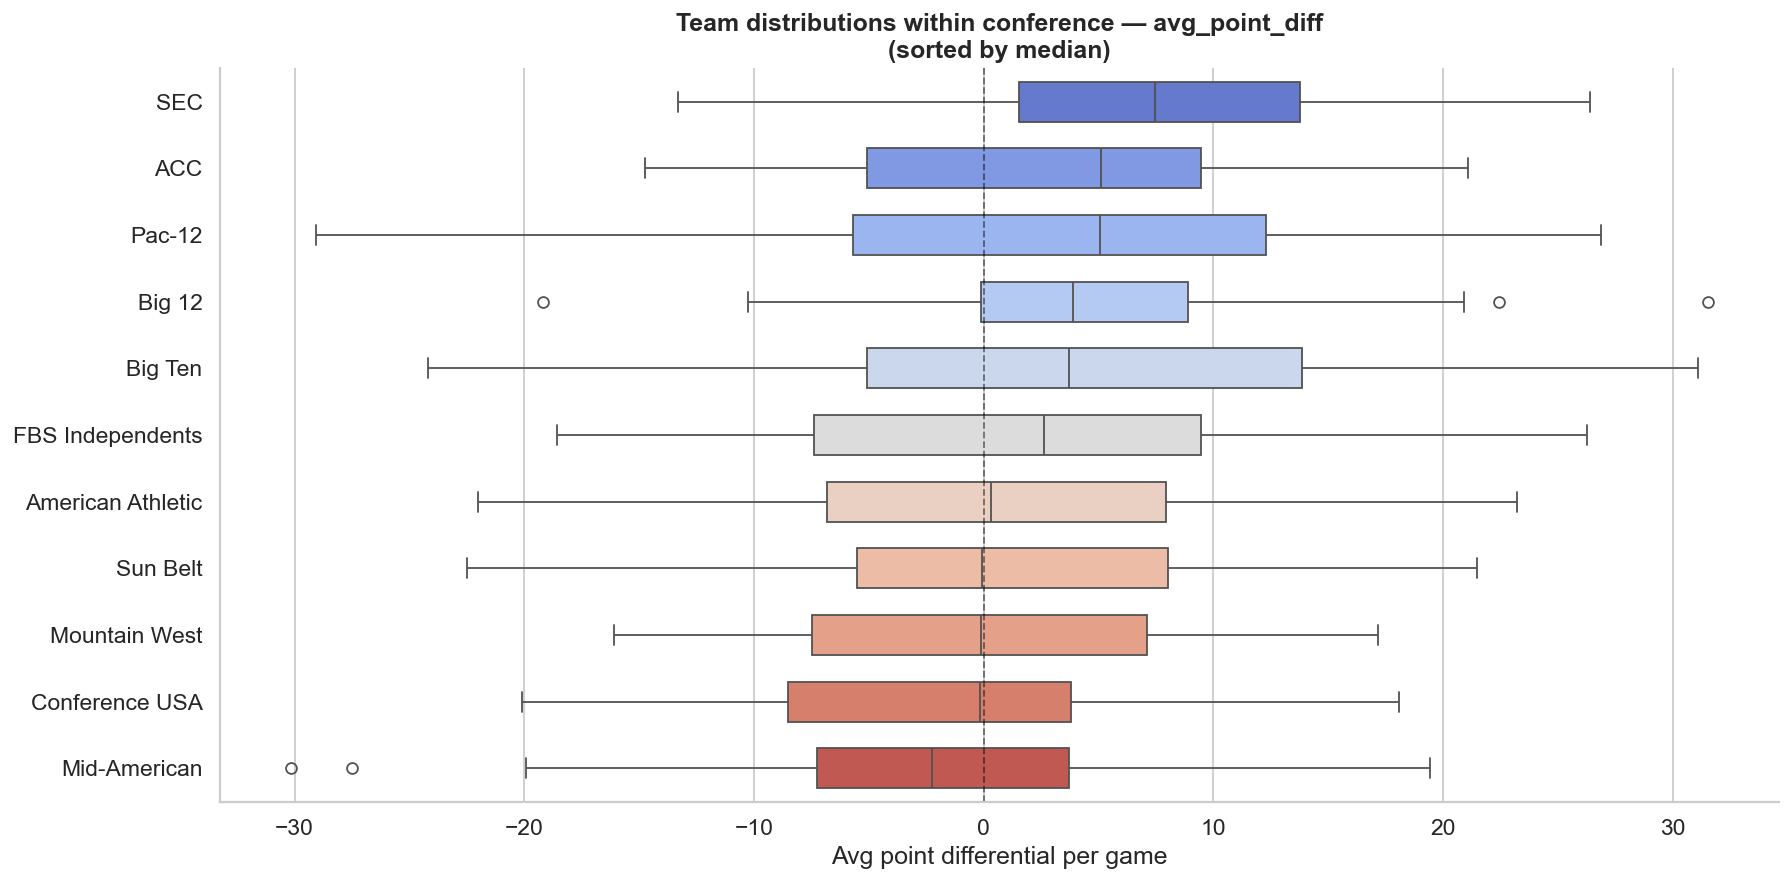

In [12]:
# Boxplot of avg_point_diff by conference, sorted by median
conf_order = (
    df.groupby("conference")["avg_point_diff"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))
df_plot = df.copy()
df_plot["conf_tier"] = df_plot.apply(
    lambda r: r["conference"] + " (P4)" if r["tier"] == "P4" else r["conference"] + " (G5)",
    axis=1
)

sns.boxplot(
    data=df,
    x="avg_point_diff",
    y="conference",
    order=conf_order,
    palette="coolwarm",
    width=0.6,
    ax=ax
)
ax.axvline(0, color="black", lw=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Avg point differential per game")
ax.set_ylabel("")
ax.set_title("Team distributions within conference — avg_point_diff\n(sorted by median)", fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
# The NB model has log(mu) = team_attack + opponent_defense + home_advantage + ...
# If conference-level scoring volume varies substantially, a conference intercept
# is justified. If it does not, team-level terms absorb it adequately.

conf_scoring = (
    df.groupby("conference")["avg_points_scored"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
    .sort_values("mean", ascending=False)
)

grand_scoring_mean = df["avg_points_scored"].mean()
grand_scoring_std  = df["avg_points_scored"].std()

print("=" * 65)
print("Q4 — Conference-level scoring volume")
print("=" * 65)
print(f"Grand mean: {grand_scoring_mean:.2f}   Grand SD: {grand_scoring_std:.2f}")
print()
print(f"{'conference':<25} {'mean':>7} {'std':>7} {'z_mean':>8}")
print("-" * 65)
for _, row in conf_scoring.iterrows():
    z = (row["mean"] - grand_scoring_mean) / grand_scoring_std
    flag = "⚠" if abs(z) > 1.0 else ""
    print(f"  {row['conference']:<23} {row['mean']:>7.2f} {row['std']:>7.2f} {z:>+8.3f}  {flag}")

Q4 — Conference-level scoring volume
Grand mean: 27.93   Grand SD: 6.69

conference                   mean     std   z_mean
-----------------------------------------------------------------
  SEC                       30.68    6.09   +0.412  
  Pac-12                    30.41    8.36   +0.371  
  Big 12                    29.90    6.17   +0.295  
  American Athletic         29.27    6.88   +0.202  
  ACC                       28.46    6.21   +0.080  
  FBS Independents          28.30    8.49   +0.055  
  Sun Belt                  27.87    5.51   -0.008  
  Big Ten                   26.60    7.49   -0.199  
  Conference USA            26.41    5.70   -0.227  
  Mountain West             25.77    6.25   -0.323  
  Mid-American              23.83    4.94   -0.613  


In [14]:
import os

# Collect findings computed above
verdict_rows = []

# Finding 1: ICC — does conference level explain enough variance to justify pooling?
icc_threshold  = 0.05
pooling_scored = "justified" if icc_scored >= icc_threshold else "marginal"
pooling_diff   = "justified" if icc_diff   >= icc_threshold else "marginal"
pooling_off    = "justified" if icc_off_epa >= icc_threshold else "marginal"
pooling_def    = "justified" if icc_def_epa >= icc_threshold else "marginal"

verdict_rows.append({
    "question": "Does conference-level variance justify pooling?",
    "finding":  f"ICC: scored={icc_scored:.3f} ({pooling_scored}), "
                f"point_diff={icc_diff:.3f} ({pooling_diff}), "
                f"off_epa={icc_off_epa:.3f} ({pooling_off}), "
                f"def_epa={icc_def_epa:.3f} ({pooling_def})",
    "decision": "Retain conference level in hierarchy" if icc_diff >= icc_threshold
                else "Conference level marginal — monitor in model fit"
})

# Finding 2: Are any conferences outliers that will dominate pooling?
outlier_confs = [
    conf for conf, mean in conf_means_diff.items()
    if abs((mean - grand_mean_diff) / grand_std_diff) > 1.5
]
verdict_rows.append({
    "question": "Are any conferences outliers that will dominate pooling?",
    "finding":  f"Outlier conferences (|z|>1.5): {outlier_confs if outlier_confs else 'none'}",
    "decision": "Flag outlier conferences for prior sensitivity check in model build"
                if outlier_confs else "No outliers — pooling should be stable"
})

# Finding 3: Does within-conference team spread justify team level?
max_team_sd   = team_spread["team_sd"].max()
verdict_rows.append({
    "question": "Does within-conference team spread justify a team level?",
    "finding":  f"Within-conference team SD range: "
                f"{team_spread['team_sd'].min():.3f}–{max_team_sd:.3f}, "
                f"mean={mean_sd:.3f}",
    "decision": "Team level clearly justified — substantial spread within every conference"
                if mean_sd > 5.0 else "Team level justified but spread is modest"
})

# Finding 4: Hierarchy confirmation
verdict_rows.append({
    "question": "Does three-level hierarchy (league → conference → team) fit the data?",
    "finding":  f"League ICC: scored={icc_scored:.3f}, diff={icc_diff:.3f}. "
                f"Substantial within-conference team spread confirms team level needed.",
    "decision": "THREE-LEVEL HIERARCHY CONFIRMED: league → conference → team"
                if icc_diff >= icc_threshold
                else "HIERARCHY NEEDS REVIEW: conference ICC below threshold"
})

verdict_df = pd.DataFrame(verdict_rows)

print("=" * 80)
print("DAY 10 VERDICT — Hierarchy Structure")
print("=" * 80)
for _, row in verdict_df.iterrows():
    print(f"\nQ: {row['question']}")
    print(f"   Finding:  {row['finding']}")
    print(f"   Decision: {row['decision']}")
print("=" * 80)

out_path = os.path.expanduser("~/cfb-analytics/artifacts/hierarchy_verdict.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
verdict_df.to_csv(out_path, index=False)
print(f"\nWritten → {out_path}")

DAY 10 VERDICT — Hierarchy Structure

Q: Does conference-level variance justify pooling?
   Finding:  ICC: scored=0.093 (justified), point_diff=0.088 (justified), off_epa=0.094 (justified), def_epa=0.070 (justified)
   Decision: Retain conference level in hierarchy

Q: Are any conferences outliers that will dominate pooling?
   Finding:  Outlier conferences (|z|>1.5): none
   Decision: No outliers — pooling should be stable

Q: Does within-conference team spread justify a team level?
   Finding:  Within-conference team SD range: 8.743–13.772, mean=10.356
   Decision: Team level clearly justified — substantial spread within every conference

Q: Does three-level hierarchy (league → conference → team) fit the data?
   Finding:  League ICC: scored=0.093, diff=0.088. Substantial within-conference team spread confirms team level needed.
   Decision: THREE-LEVEL HIERARCHY CONFIRMED: league → conference → team

Written → /Users/kevinjohnson/cfb-analytics/artifacts/hierarchy_verdict.csv
